<a href="https://colab.research.google.com/github/ayslanleal/esc-classification-mlp/blob/main/sbcnn_gtzan_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SB-CNN GTZAN — Treinamento + Clustering (t-SNE / Silhouette)
Pipeline completo: carrega patches → treina SB-CNN → extrai ativações Dense(64) → t-SNE + silhouette

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Activation,
    Flatten, Dense, Dropout, Input
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD

N_CLASSES = 10
RANDOM_STATE = 42
EPOCHS       = 100
BATCH_SIZE   = 32

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Activation,
    Flatten, Dense, Dropout, Input
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

N_CLASSES = 10


class Model:

    def sbcnn(self, n_classes: int = N_CLASSES) -> Sequential:
        """
        SB-CNN conforme Salamon & Bello (2017).

        Arquitetura:
            l1: Conv(24, 5x5) → MaxPool(4x2) → ReLU
            l2: Conv(48, 5x5) → MaxPool(4x2) → ReLU
            l3: Conv(48, 5x5) → ReLU
            l4: Dropout(0.5)  → Dense(64)    → ReLU
            l5: Dropout(0.5)  → Dense(n_classes) → Softmax

        Input: (128, 128, 1) — log-mel-spectrogram patch de 3s
        """
        model = Sequential([
            Input(shape=(128, 128, 1)),

            # l1
            Conv2D(24, (5, 5), padding='same'),
            MaxPool2D(pool_size=(4, 2)),
            Activation('relu'),

            # l2
            Conv2D(48, (5, 5), padding='same'),
            MaxPool2D(pool_size=(4, 2)),
            Activation('relu'),

            # l3 (sem pooling)
            Conv2D(48, (5, 5), padding='valid'),
            Activation('relu'),

            # flatten antes das densas
            Flatten(),

            # l4 — dropout na entrada da camada densa
            Dropout(0.5),
            Dense(64, kernel_regularizer=l2(0.001)),
            Activation('relu'),

            # l5 — dropout na entrada da camada de saída
            Dropout(0.5),
            Dense(n_classes, kernel_regularizer=l2(0.001)),
            Activation('softmax'),
        ])

        model.compile(
            optimizer=Adam(learning_rate=1e-4),
            loss='sparse_categorical_crossentropy',  # labels como inteiros
            metrics=['accuracy'],
        )

        return model

## 1. Carrega dataset

In [19]:
df = pd.read_pickle('./gtzan.pkl')
print('Shape:', df.shape)
print(df['label'].value_counts())

Shape: (9990, 4)
label
blues        1000
classical    1000
country      1000
disco        1000
hiphop       1000
metal        1000
reggae       1000
pop          1000
rock         1000
jazz          990
Name: count, dtype: int64


## 2. Prepara features e labels

In [21]:
le = LabelEncoder()
y  = le.fit_transform(df['label'].values)
X  = np.stack(df['features'].values)[..., np.newaxis]  # (N, 128, 128, 1)

print('Classes:', le.classes_)
print('X shape:', X.shape)
print('y shape:', y.shape)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
X shape: (9990, 128, 128, 1)
y shape: (9990,)


## 3. Divisão treino / teste — 80/20 estratificado por áudio original

O split é feito sobre os **arquivos originais** (evita data leakage entre patches do mesmo áudio).

In [22]:
# identificar arquivos únicos e seus labels
df_files = df[['path', 'label']].drop_duplicates()

train_paths, test_paths = train_test_split(
    df_files['path'].values,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_files['label'].values,
)

train_mask = df['path'].isin(train_paths)
test_mask  = df['path'].isin(test_paths)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Treino : {X_train.shape[0]} patches ({len(train_paths)} áudios)')
print(f'Teste  : {X_test.shape[0]} patches ({len(test_paths)} áudios)')

Treino : 7990 patches (799 áudios)
Teste  : 2000 patches (200 áudios)


## 4. Treina SB-CNN

In [23]:
model = Model().sbcnn(n_classes=len(le.classes_))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 24)   │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 64, 48)     │        28,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 32, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 32, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 28, 48)      │        57,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 4, 28, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       344,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,898 (1.65 MB)

 Trainable params: 431,898 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'save_models_1/sbcnn_gtzan.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stop],
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1186 - loss: 3.2495
Epoch 1: val_accuracy improved from None to 0.22450, saving model to save_models_1/sbcnn_gtzan.keras

Epoch 1: finished saving model to save_models_1/sbcnn_gtzan.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.1310 - loss: 2.5998 - val_accuracy: 0.2245 - val_loss: 2.2750
Epoch 2/100
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2193 - loss: 2.2553
Epoch 2: val_accuracy improved from 0.22450 to 0.39950, saving model to save_models_1/sbcnn_gtzan.keras

Epoch 2: finished saving model to save_models_1/sbcnn_gtzan.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2597 - loss: 2.1633 - val_accuracy: 0.3995 - val_loss: 1.8651
Epoch 3/100
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3350 - loss: 1.9468
Epoch 3: val_accuracy improved from 0.39950 to 0.45350, saving model to save_models_1/sbcnn_gtzan.keras

Epoch 3: finished saving model to save_models_1/sbcnn_g

## 5. Curvas de acurácia e loss

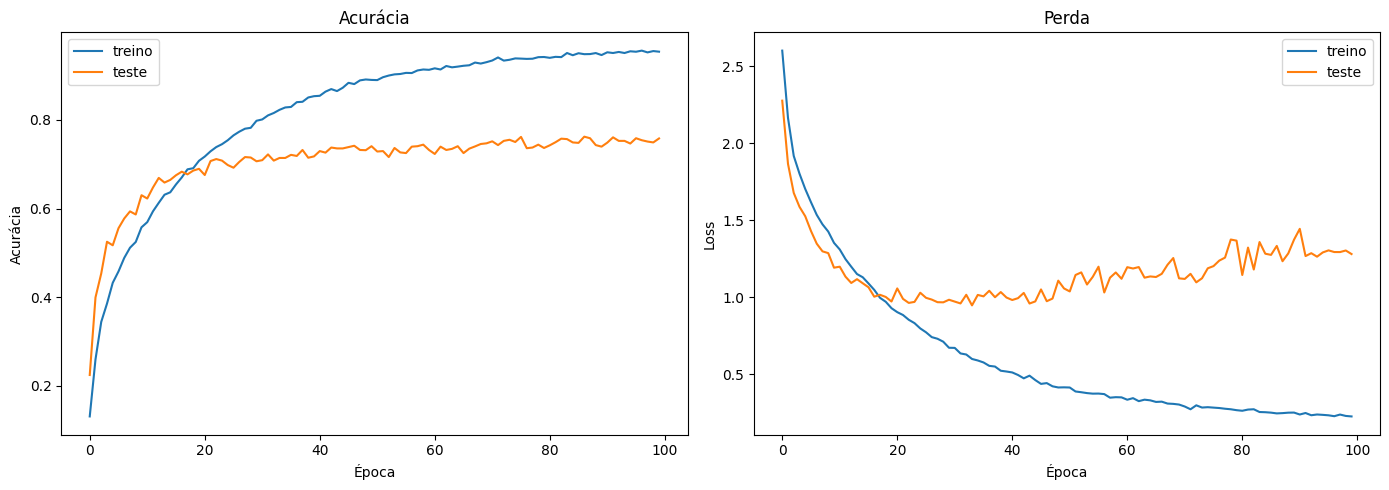

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='treino')
axes[0].plot(history.history['val_accuracy'], label='teste')
axes[0].set_title('Acurácia')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='treino')
axes[1].plot(history.history['val_loss'], label='teste')
axes[1].set_title('Perda')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/sbcnn_gtzan_curvas.png', dpi=150)
plt.show()

## 6. Avaliação — classification report e matriz de confusão

In [26]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Loss teste : {loss:.4f}')
print(f'Acurácia   : {acc:.4f}')

y_pred = model.predict(X_test).argmax(axis=1)
print('\n', classification_report(y_test, y_pred, target_names=le.classes_))

Loss teste : 1.3325
Acurácia   : 0.7620
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

               precision    recall  f1-score   support

       blues       0.83      0.78      0.81       200
   classical       0.86      0.95      0.90       200
     country       0.63      0.78      0.70       200
       disco       0.79      0.43      0.56       200
      hiphop       0.77      0.81      0.79       200
        jazz       0.79      0.96      0.87       200
       metal       0.96      0.89      0.92       200
         pop       0.67      0.77      0.71       200
      reggae       0.74      0.77      0.75       200
        rock       0.62      0.48      0.54       200

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.75      2000
weighted avg       0.76      0.76      0.75      2000



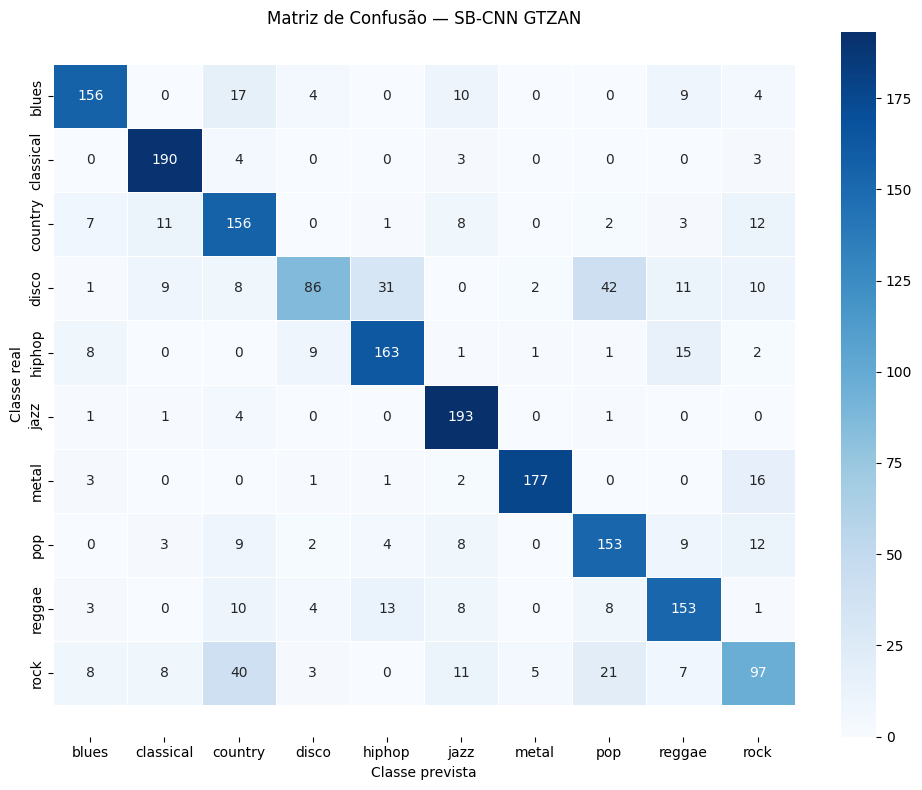

In [27]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.title('Matriz de Confusão — SB-CNN GTZAN')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.tight_layout()
plt.savefig('figures/sbcnn_gtzan_matriz.png', dpi=150)
plt.show()

## 7. Extração de ativações — penúltima camada Dense(64)

In [29]:
# Encontra o índice da camada Dense(64) e pega a Activation('relu') seguinte
dense64_idx = next(
    i for i, layer in enumerate(model.layers)
    if hasattr(layer, 'units') and layer.units == 64
)
relu64_idx = dense64_idx + 1  # Activation('relu') logo após Dense(64)

print(f"Dense(64) → layer[{dense64_idx}]: {model.layers[dense64_idx].name}")
print(f"ReLU      → layer[{relu64_idx}]: {model.layers[relu64_idx].name}")

# modelo auxiliar que retorna as ativações do ReLU após Dense(64)
_ = model(tf.zeros((1, 128, 128, 1)))  # garante que o modelo foi chamado ao menos uma vez

hidden_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[relu64_idx].output,
)

train_hidden = hidden_model.predict(X_train, verbose=0)
test_hidden  = hidden_model.predict(X_test,  verbose=0)

print('Ativações treino:', train_hidden.shape)
print('Ativações teste :', test_hidden.shape)

Dense(64) → layer[10]: dense_2
ReLU      → layer[11]: activation_8
Ativações treino: (7990, 64)
Ativações teste : (2000, 64)


## 8. t-SNE — visualização do espaço latente

In [30]:
def plot_tsne(features, labels, le, title, save_path=None):
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=40, n_iter=1000)
    proj = tsne.fit_transform(features)

    plt.figure(figsize=(12, 8))
    palette = sns.color_palette('tab10', len(le.classes_))
    for i, cls in enumerate(le.classes_):
        mask = labels == i
        plt.scatter(proj[mask, 0], proj[mask, 1], label=cls, s=15, alpha=0.7, color=palette[i])

    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return proj

Rodando t-SNE no conjunto de treino...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


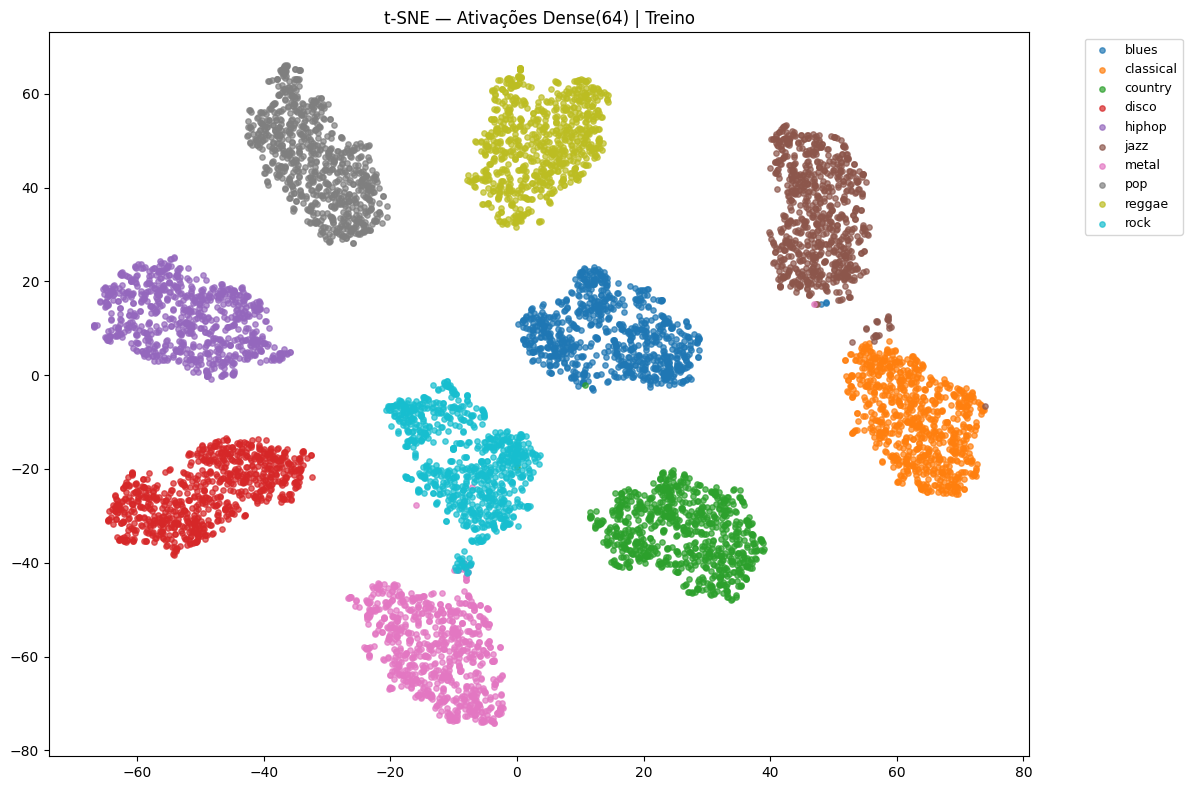

In [31]:
print('Rodando t-SNE no conjunto de treino...')
proj_train = plot_tsne(
    train_hidden, y_train, le,
    title='t-SNE — Ativações Dense(64) | Treino',
    save_path='figures/sbcnn_gtzan_tsne_treino.png',
)

Rodando t-SNE no conjunto de teste...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


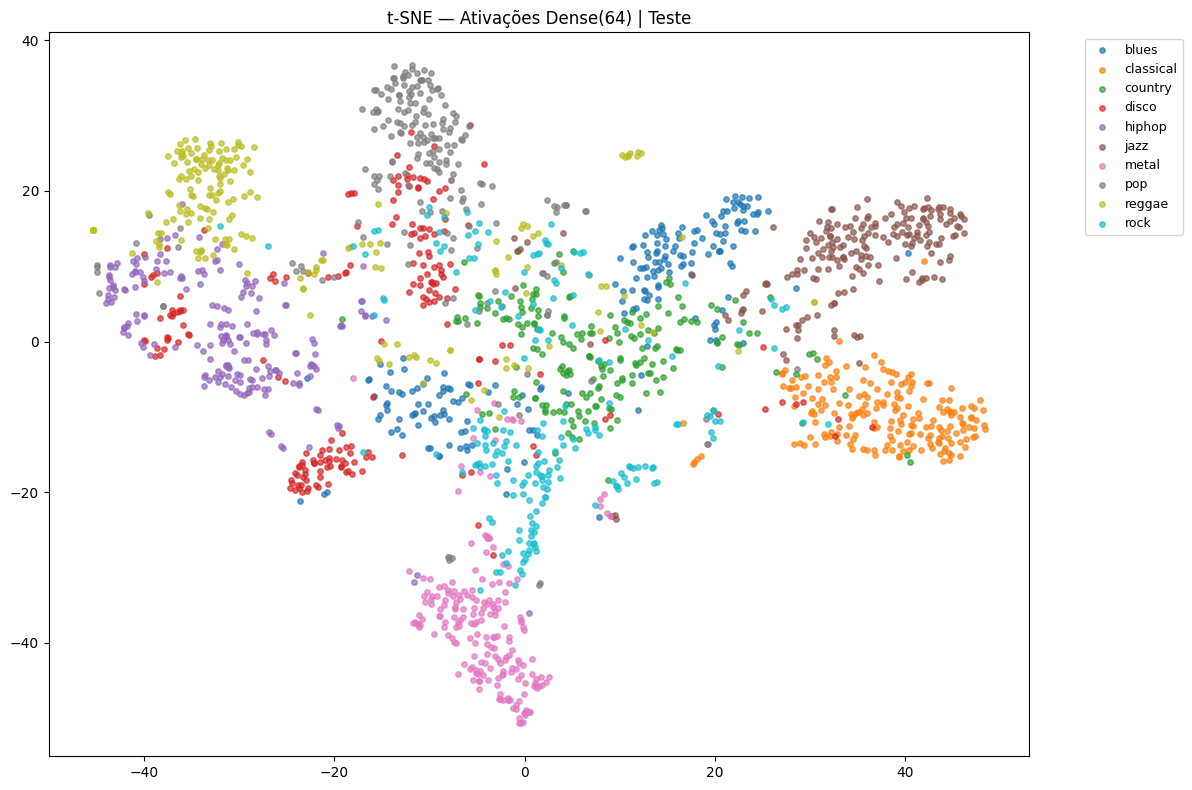

In [32]:
print('Rodando t-SNE no conjunto de teste...')
proj_test = plot_tsne(
    test_hidden, y_test, le,
    title='t-SNE — Ativações Dense(64) | Teste',
    save_path='figures/sbcnn_gtzan_tsne_teste.png',
)

## 9. Silhouette Score

In [33]:
sil_train = silhouette_score(proj_train, y_train)
sil_test  = silhouette_score(proj_test,  y_test)

print(f'Silhouette Score — Treino : {sil_train:.4f}')
print(f'Silhouette Score — Teste  : {sil_test:.4f}')
print()
print('Interpretação:')
print('  ~1.0 → classes bem separadas')
print('  ~0.0 → classes sobrepostas')
print('  < 0  → amostras mais próximas de outra classe')

Silhouette Score — Treino : 0.6368
Silhouette Score — Teste  : 0.1784

Interpretação:
  ~1.0 → classes bem separadas
  ~0.0 → classes sobrepostas
  < 0  → amostras mais próximas de outra classe


## 10. Silhouette por classe

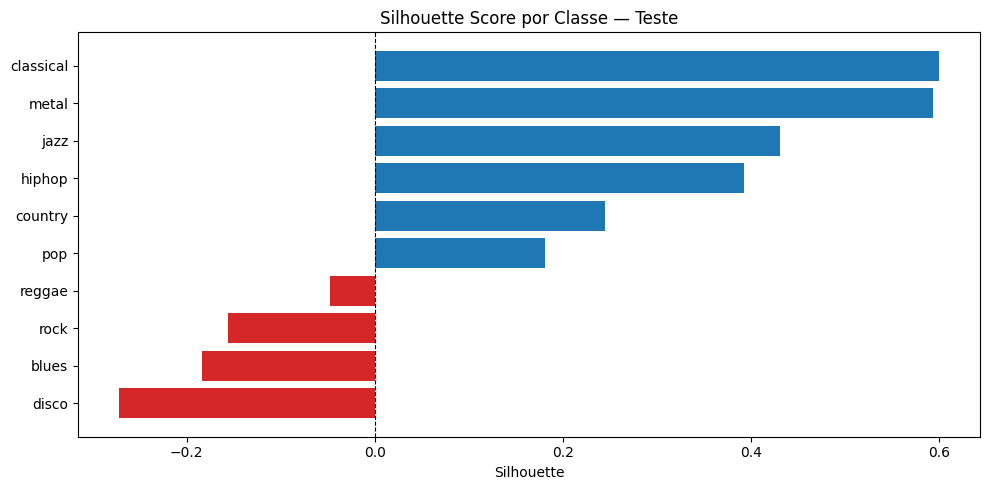

   classe  silhouette
    disco   -0.271915
    blues   -0.184072
     rock   -0.156141
   reggae   -0.047626
      pop    0.180673
  country    0.245244
   hiphop    0.392644
     jazz    0.431192
    metal    0.593809
classical    0.599979


In [34]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(proj_test, y_test)
sil_per_class = {
    cls: sil_samples[y_test == i].mean()
    for i, cls in enumerate(le.classes_)
}

sil_df = pd.DataFrame(sil_per_class.items(), columns=['classe', 'silhouette']).sort_values('silhouette')

plt.figure(figsize=(10, 5))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in sil_df['silhouette']]
plt.barh(sil_df['classe'], sil_df['silhouette'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Silhouette Score por Classe — Teste')
plt.xlabel('Silhouette')
plt.tight_layout()
plt.savefig('figures/sbcnn_gtzan_silhouette_classes.png', dpi=150)
plt.show()

print(sil_df.to_string(index=False))